<a href="https://colab.research.google.com/github/shaikaalima06-gif/PRODIGY_ML_01/blob/main/prodigy_task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/train.csv')

# Defining the specific columns from your dataset
features = ['Gr Liv Area', 'Bedroom AbvGr', 'Full Bath']
target = 'SalePrice'

# Clean the data by selecting relevant columns and dropping rows with missing values
data = df[features + [target]].dropna()

print("First 5 rows of selected data:")
print(data.head())

First 5 rows of selected data:
   Gr Liv Area  Bedroom AbvGr  Full Bath  SalePrice
0         1656              3          1     215000
1          896              2          1     105000
2         1329              3          1     172000
3         2110              3          2     244000
4         1629              3          2     189900


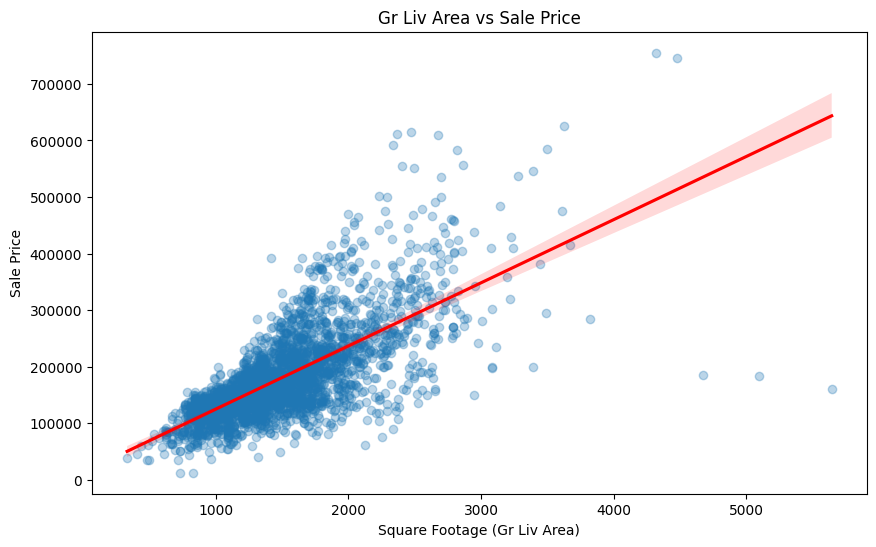

In [3]:
# Check relationship between Square Footage and Sale Price
plt.figure(figsize=(10, 6))
sns.regplot(x='Gr Liv Area', y='SalePrice', data=data, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Gr Liv Area vs Sale Price')
plt.xlabel('Square Footage (Gr Liv Area)')
plt.ylabel('Sale Price')
plt.show()

In [4]:
# Features (X) and Target (y)
X = data[features]
y = data[target]

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training size: {X_train.shape[0]}")
print(f"Testing size: {X_test.shape[0]}")

Training size: 2344
Testing size: 586


In [5]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# View the coefficients (how much each feature affects the price)
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(f"Intercept: {model.intercept_}")
print(coeff_df)

Intercept: 50339.864299252426
                Coefficient
Gr Liv Area      113.382180
Bedroom AbvGr -28772.417000
Full Bath      26227.187194


In [6]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: ${rmse:,.2f}")
print(f"R-squared Score: {r2:.4f}")

Root Mean Squared Error: $55,665.69
R-squared Score: 0.6135


In [7]:
# Predict for a house with 2000 sq ft, 3 bedrooms, and 2 bathrooms
# Note: Format must match [Gr Liv Area, Bedroom AbvGr, Full Bath]
new_house = [[2000, 3, 2]]
prediction = model.predict(new_house)

print(f"The estimated price for this house is: ${prediction[0]:,.2f}")

The estimated price for this house is: $243,241.35


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [8]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [   113.38218042 -28772.41700026  26227.18719409]
Intercept: 50339.864299252426
